In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv("Social_Network_Ads.csv")
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
x = data[['Age', 'EstimatedSalary']]
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [5]:
y = data['Purchased']
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.30,random_state=43)

In [7]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

KNeighborsClassifier()

In [10]:
age = float(input("Enter Age: "))
salary = float(input("Enter Estimated Salary: "))

input_data = [[age, salary]]

input_data = scaler.transform(input_data)

prediction = model.predict(input_data)

if prediction[0] == 1:
    print("Customer will purchase the product")
else:
    print("Customer will not purchase the product")

Enter Age: 20
Enter Estimated Salary: 200000
Customer will purchase the product


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy = 0.875
Accuracy: 87.50%


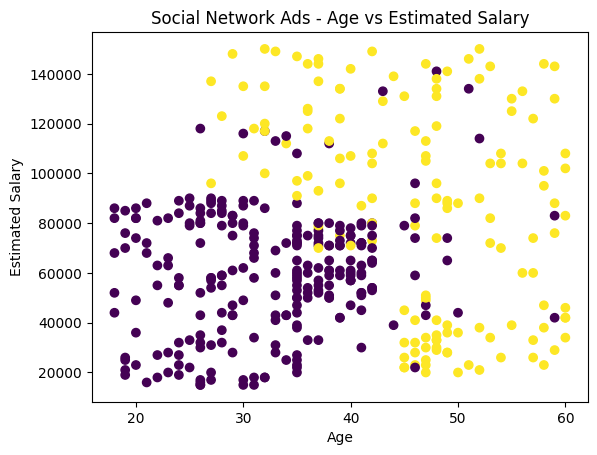

In [13]:
import matplotlib.pyplot as plt
plt.scatter(data['Age'],data['EstimatedSalary'],c=data['Purchased'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Social Network Ads - Age vs Estimated Salary")
plt.show()

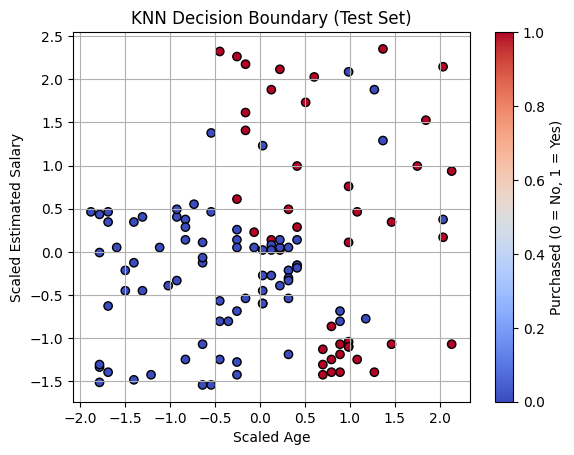

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define the bounds of the domain to plot
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

# Plot the scaled test data points
scatter = plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.coolwarm)

plt.xlabel('Scaled Age')
plt.ylabel('Scaled Estimated Salary')
plt.title('KNN Decision Boundary (Test Set)')
plt.colorbar(scatter, label='Purchased (0 = No, 1 = Yes)')
plt.grid(True)
plt.show()